In [1]:
import jax
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from astropy.io import fits
import os
os.environ["WEBBPSF_PATH"] = 'webbpsf-data'
os.environ["WEBBPSF_EXT_PATH"] = 'webbpsf-data'
os.environ["PYSYN_CDBS"] = "cdbs"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.15'

In [2]:
names = ["jw04050003001_03106_00001_nrca2_calints", "jw04050006001_03106_00001_nrca2_calints",
         "jw04050015001_03106_00001_nrca2_calints", "jw04050017001_03106_00001_nrca2_calints",
         "jw04050022001_03106_00001_nrca2_calints"]

images = []

for name in names:
    fits_image_filepath = "stellar_psf_images/" + str(name) + ".fits"
    hdul = fits.open(fits_image_filepath)
    images.append(hdul['SCI'].data[0,:,:])

In [3]:
from utils.stellar_psfs import LinearStellar_PSF

/home/mihirkondapalli/anaconda3/envs/jwst_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


webbpsf_ext log messages of level WARN and above will be shown.
webbpsf_ext log outputs will be directed to the screen.
Could not import CuPy. Setting: use_gpu=False (i.e., using CPU operations).


Filename: Fits/hd117214_H_pol.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     496   ()      
  1  SCI           1 ImageHDU       138   (281, 281, 4)   float32   
  2  DQ            3 ImageHDU        64   (281, 281, 2)   uint8   


Text(0.5, 1.0, 'Image from Fits File')

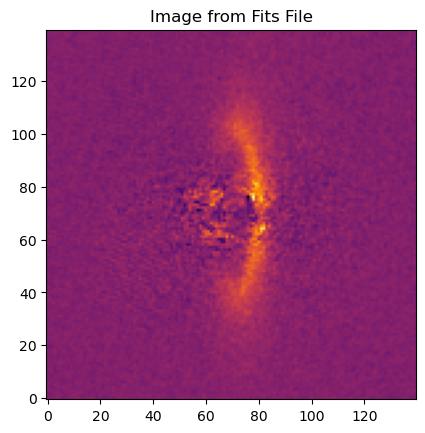

In [4]:
from statistical_analysis.optimize_framework import OptimizeUtils

name = "hd117214_H_pol"
fits_image_filepath = "Fits/" + name + ".fits"
hdul = fits.open(fits_image_filepath)

#Displays File Info
hdul.info()

# Gets Image
target_image = OptimizeUtils.process_image(hdul['SCI'].data[1,:,:])

# Displays Image
plt.imshow(target_image, origin='lower', cmap='inferno')
plt.title("Image from Fits File")

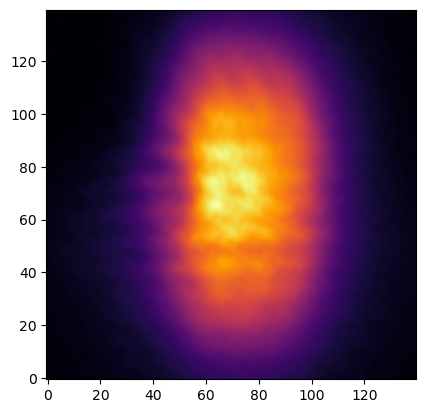

In [5]:
images = np.array(images)
lsp = LinearStellar_PSF(images)

plt.imshow(lsp.generate(target_image, 0.2*np.ones(5)), origin='lower', cmap='inferno')